In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
vaccinedf = pd.read_csv("/workspace/COVIDResearch/COVIDVaccinationsUSCounty.csv", encoding='latin1')

/tmp/ipykernel_2149/1221815491.py:1: DtypeWarning: Columns (8,18,20,28,30,32,34,36,38,67,68,71,72,74,76,78) have mixed types. Specify dtype option on import or set low_memory=False.
  vaccinedf = pd.read_csv("/workspace/COVIDResearch/COVIDVaccinationsUSCounty.csv", encoding='latin1')


# EDA

In [3]:
vaccinedf

,Date,FIPS,MMWR_week,Recip_County,Recip_State,Completeness_pct,Administered_Dose1_Recip,Administered_Dose1_Pop_Pct,Administered_Dose1_Recip_5Plus,Administered_Dose1_Recip_5PlusPop_Pct,...,Census2019_18PlusPop,Census2019_65PlusPop,Bivalent_Booster_5Plus,Bivalent_Booster_5Plus_Pop_Pct,Bivalent_Booster_12Plus,Bivalent_Booster_12Plus_Pop_Pct,Bivalent_Booster_18Plus,Bivalent_Booster_18Plus_Pop_Pct,Bivalent_Booster_65Plus,Bivalent_Booster_65Plus_Pop_Pct
0,05/10/2023,51820,19,Waynesboro city,VA,78.1,"11,432",50.5,"11,388",54.2,...,"17,265","4,031",757,3.6,752,4.0,731,4.2,386,9.6
1,05/10/2023,51171,19,Shenandoah County,VA,78.1,"25,330",58.1,"25,275",61.3,...,"34,452","9,690","4,980",12.1,"4,955",13.2,"4,891",14.2,"3,116",32.2
2,05/10/2023,51157,19,Rappahannock County,VA,78.1,"5,026",68.2,"5,003",70.6,...,"6,174","2,053",962,13.6,950,14.4,934,15.1,603,29.4
3,05/10/2023,51183,19,Sussex County,VA,78.1,"4,692",42.0,"4,691",43.8,...,"9,462","2,070",656,6.1,656,6.5,656,6.9,129,6.2
4,05/10/2023,51700,19,Newport News city,VA,78.1,"111,702",62.3,"111,200",66.9,...,"137,743","23,892","14,101",8.5,"13,904",9.3,"13,533",9.8,"6,320",26.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80125,12/13/2020,51091,51,Highland County,VA,0.0,0,0.0,NaN,NaN,...,"1,898",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
80126,12/13/2020,51730,51,Petersburg city,VA,0.0,0,0.0,NaN,NaN,...,"24,275",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
80127,12/13/2020,51037,51,Charlotte County,VA,0.0,0,0.0,NaN,NaN,...,"9,396",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
80128,12/13/2020,51065,51,Fluvanna County,VA,0.0,0,0.0,NaN,NaN,...,"21,864",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
vaccinedf.columns

Index(['Date', 'FIPS', 'MMWR_week', 'Recip_County', 'Recip_State',
       'Completeness_pct', 'Administered_Dose1_Recip',
       'Administered_Dose1_Pop_Pct', 'Administered_Dose1_Recip_5Plus',
       'Administered_Dose1_Recip_5PlusPop_Pct',
       'Administered_Dose1_Recip_12Plus',
       'Administered_Dose1_Recip_12PlusPop_Pct',
       'Administered_Dose1_Recip_18Plus',
       'Administered_Dose1_Recip_18PlusPop_Pct',
       'Administered_Dose1_Recip_65Plus',
       'Administered_Dose1_Recip_65PlusPop_Pct', 'Series_Complete_Yes',
       'Series_Complete_Pop_Pct', 'Series_Complete_5Plus',
       'Series_Complete_5PlusPop_Pct', 'Series_Complete_5to17',
       'Series_Complete_5to17Pop_Pct', 'Series_Complete_12Plus',
       'Series_Complete_12PlusPop_Pct', 'Series_Complete_18Plus',
       'Series_Complete_18PlusPop_Pct', 'Series_Complete_65Plus',
       'Series_Complete_65PlusPop_Pct', 'Booster_Doses',
       'Booster_Doses_Vax_Pct', 'Booster_Doses_5Plus',
       'Booster_Doses_5Plus_Vax

In [5]:
nhgis5 = pd.read_csv("/workspace/COVIDResearch/nhgis0003_ds254_20215_county.csv", encoding='latin1')
nhgis2019 = pd.read_csv("/workspace/COVIDResearch/nhgis0003_ds243_2019_county.csv", encoding='latin1')
nhgis2021 = pd.read_csv("/workspace/COVIDResearch/nhgis0003_ds253_2021_county.csv", encoding='latin1')

In [6]:
nhgis5

,GISJOIN,YEAR,STUSAB,REGIONA,DIVISIONA,STATE,STATEA,COUNTY,COUNTYA,COUSUBA,...,AOP8M019,AOP8M020,AOP8M021,AOP8M022,AOP8M023,AOP8M024,AOP8M025,AOQIM001,AOQJM001,AORGM001
0,G5100010,2017-2021,VA,NaN,NaN,Virginia,51,Accomack County,1,NaN,...,327,436,334,418,308,98,109,5803,64566342,4109
1,G5100030,2017-2021,VA,NaN,NaN,Virginia,51,Albemarle County,3,NaN,...,422,754,444,1103,837,487,440,3359,213308039,5824
2,G5100050,2017-2021,VA,NaN,NaN,Virginia,51,Alleghany County,5,NaN,...,211,241,213,187,131,56,82,5345,31738951,5202
3,G5100070,2017-2021,VA,NaN,NaN,Virginia,51,Amelia County,7,NaN,...,161,354,234,244,158,104,37,10638,48944215,12345
4,G5100090,2017-2021,VA,NaN,NaN,Virginia,51,Amherst County,9,NaN,...,250,372,276,347,301,55,155,3561,74246632,5630
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,G5108000,2017-2021,VA,NaN,NaN,Virginia,51,Suffolk city,800,NaN,...,445,726,612,691,536,192,195,3471,196076469,4571
129,G5108100,2017-2021,VA,NaN,NaN,Virginia,51,Virginia Beach city,810,NaN,...,1372,1803,1688,1990,1270,640,631,1205,344010152,1807
130,G5108200,2017-2021,VA,NaN,NaN,Virginia,51,Waynesboro city,820,NaN,...,308,278,294,350,298,127,111,6024,70040175,9413
131,G5108300,2017-2021,VA,NaN,NaN,Virginia,51,Williamsburg city,830,NaN,...,153,172,191,279,220,108,129,7470,60563980,10653


In [7]:
nhgis5.columns

Index(['GISJOIN', 'YEAR', 'STUSAB', 'REGIONA', 'DIVISIONA', 'STATE', 'STATEA',
       'COUNTY', 'COUNTYA', 'COUSUBA', 'PLACEA', 'TRACTA', 'BLKGRPA',
       'CONCITA', 'AIANHHA', 'RES_ONLYA', 'TRUSTA', 'AIHHTLI', 'AITSA',
       'ANRCA', 'CBSAA', 'CSAA', 'METDIVA', 'NECTAA', 'CNECTAA', 'NECTADIVA',
       'UAA', 'CDCURRA', 'SLDUA', 'SLDLA', 'ZCTA5A', 'SUBMCDA', 'SDELMA',
       'SDSECA', 'SDUNIA', 'PCI', 'PUMAA', 'GEO_ID', 'BTTRA', 'BTBGA',
       'TL_GEO_ID', 'NAME_E', 'AOP8E001', 'AOP8E002', 'AOP8E003', 'AOP8E004',
       'AOP8E005', 'AOP8E006', 'AOP8E007', 'AOP8E008', 'AOP8E009', 'AOP8E010',
       'AOP8E011', 'AOP8E012', 'AOP8E013', 'AOP8E014', 'AOP8E015', 'AOP8E016',
       'AOP8E017', 'AOP8E018', 'AOP8E019', 'AOP8E020', 'AOP8E021', 'AOP8E022',
       'AOP8E023', 'AOP8E024', 'AOP8E025', 'AOQIE001', 'AOQJE001', 'AORGE001',
       'NAME_M', 'AOP8M001', 'AOP8M002', 'AOP8M003', 'AOP8M004', 'AOP8M005',
       'AOP8M006', 'AOP8M007', 'AOP8M008', 'AOP8M009', 'AOP8M010', 'AOP8M011',
      

In [8]:
nhgis5["TL_GEO_ID"]

0      51001
1      51003
2      51005
3      51007
4      51009
       ...  
128    51800
129    51810
130    51820
131    51830
132    51840
Name: TL_GEO_ID, Length: 133, dtype: int64

In [9]:
cdccomms = pd.read_csv("/workspace/COVIDResearch/cdc_key_communications.csv", encoding='latin1')
cdcsentiment = pd.read_csv("/workspace/COVIDResearch/cdc_monthly_sentiment.csv", encoding='latin1')


In [10]:
cdccomms.head()

,date,title,event_type,valence,month,year
0,2021-01-06,HHS announces $22B in COVID testing and vaccin...,funding,1,2021-01,2021
1,2021-01-12,CDC recommends COVID-19 vaccination for adults...,guidance,1,2021-01,2021
2,2021-01-21,"CDC updates quarantine guidance, supports mask...",guidance,1,2021-01,2021
3,2021-02-05,CDC releases first month vaccination demograph...,data_release,0,2021-02,2021
4,2021-02-28,CDC Director signs ACIP recommendation for J&J...,approval,1,2021-02,2021


In [11]:
cdcsentiment.head()
# valance = 1 is good, 0 is neutral, -1 is bad news

,month,avg_valence,n_communications,positive_comms,negative_comms
0,2021-01,1.000000,3,3,0
1,2021-02,0.500000,2,1,0
2,2021-03,1.000000,3,3,0
3,2021-04,0.250000,4,2,1
4,2021-05,0.333333,3,2,1


## Data Cleaning

In [12]:
# Cleaning Vaccine
vaccinedf.dtypes

Date                                object
FIPS                                object
MMWR_week                            int64
Recip_County                        object
Recip_State                         object
                                    ...   
Bivalent_Booster_12Plus_Pop_Pct    float64
Bivalent_Booster_18Plus             object
Bivalent_Booster_18Plus_Pop_Pct    float64
Bivalent_Booster_65Plus             object
Bivalent_Booster_65Plus_Pop_Pct    float64
Length: 80, dtype: object

In [16]:
vaccinedf['Date'] = pd.to_datetime(vaccinedf['Date'], format='%m/%d/%Y')
count_cols = ['Administered_Dose1_Recip', 'Series_Complete_Yes', 'Booster_Doses', 'Census2019']
for col in count_cols:
    vaccinedf[col] = vaccinedf[col].astype(str).str.replace(',', '', regex=False)
    vaccinedf[col] = pd.to_numeric(vaccinedf[col], errors='coerce')


In [17]:
vaccinedf.head()

,Date,FIPS,MMWR_week,Recip_County,Recip_State,Completeness_pct,Administered_Dose1_Recip,Administered_Dose1_Pop_Pct,Administered_Dose1_Recip_5Plus,Administered_Dose1_Recip_5PlusPop_Pct,...,Census2019_18PlusPop,Census2019_65PlusPop,Bivalent_Booster_5Plus,Bivalent_Booster_5Plus_Pop_Pct,Bivalent_Booster_12Plus,Bivalent_Booster_12Plus_Pop_Pct,Bivalent_Booster_18Plus,Bivalent_Booster_18Plus_Pop_Pct,Bivalent_Booster_65Plus,Bivalent_Booster_65Plus_Pop_Pct
0,2023-05-10,51820,19,Waynesboro city,VA,78.1,11432.0,50.5,"11,388",54.2,...,"17,265","4,031",757,3.6,752,4.0,731,4.2,386,9.6
1,2023-05-10,51171,19,Shenandoah County,VA,78.1,25330.0,58.1,"25,275",61.3,...,"34,452","9,690","4,980",12.1,"4,955",13.2,"4,891",14.2,"3,116",32.2
2,2023-05-10,51157,19,Rappahannock County,VA,78.1,5026.0,68.2,"5,003",70.6,...,"6,174","2,053",962,13.6,950,14.4,934,15.1,603,29.4
3,2023-05-10,51183,19,Sussex County,VA,78.1,4692.0,42.0,"4,691",43.8,...,"9,462","2,070",656,6.1,656,6.5,656,6.9,129,6.2
4,2023-05-10,51700,19,Newport News city,VA,78.1,111702.0,62.3,"111,200",66.9,...,"137,743","23,892","14,101",8.5,"13,904",9.3,"13,533",9.8,"6,320",26.5


In [19]:
vaccinedf['Recip_County'].value_counts()

Recip_County
Waynesboro city        598
Shenandoah County      598
Rappahannock County    598
Sussex County          598
Newport News city      598
                      ... 
Floyd County           598
Henrico County         598
Portsmouth city        598
Martinsville city      598
Unknown County         596
Name: count, Length: 134, dtype: int64

/tmp/ipykernel_2149/1960164661.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


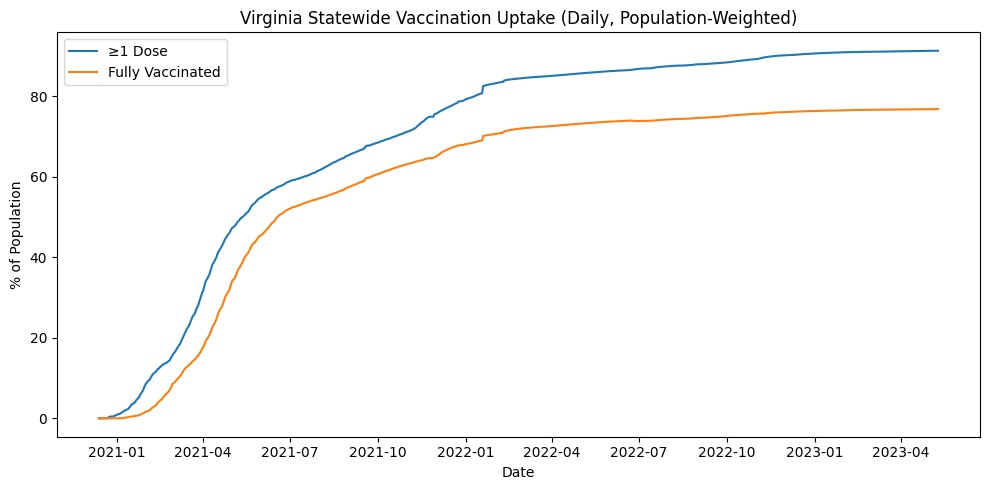

In [18]:
daily = (
    vaccinedf.groupby('Date')
    .apply(lambda g: pd.Series({
        'dose1_pct': (g['Administered_Dose1_Recip'].sum() / g['Census2019'].sum()) * 100,
        'complete_pct': (g['Series_Complete_Yes'].sum() / g['Census2019'].sum()) * 100,
    }))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=daily, x='Date', y='dose1_pct', label='≥1 Dose', ax=ax)
sns.lineplot(data=daily, x='Date', y='complete_pct', label='Fully Vaccinated', ax=ax)
ax.set_ylabel('% of Population')
ax.set_title('Virginia Statewide Vaccination Uptake (Daily, Population-Weighted)')
ax.legend()
plt.tight_layout()
plt.show()

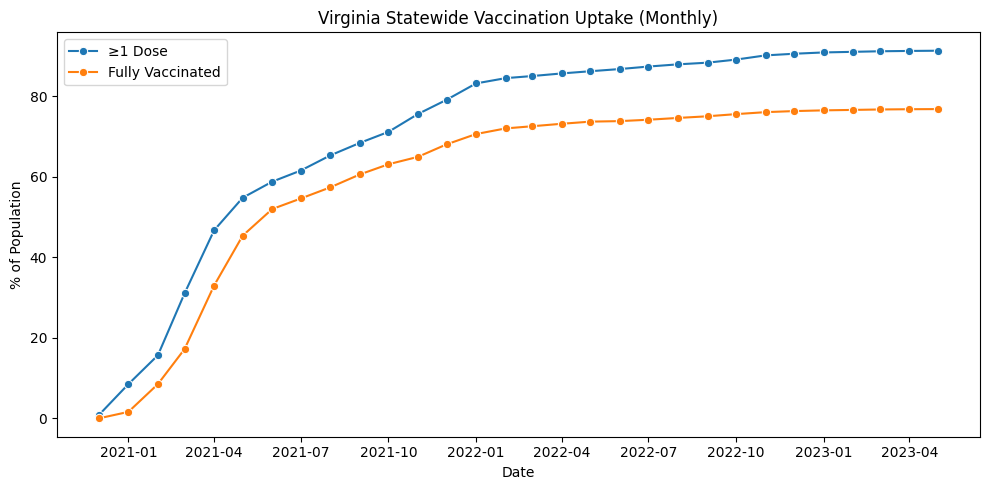

In [20]:
monthly = (
    daily.set_index('Date')[['dose1_pct', 'complete_pct']]
    .resample('MS')
    .last()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=monthly, x='Date', y='dose1_pct', marker='o', label='≥1 Dose', ax=ax)
sns.lineplot(data=monthly, x='Date', y='complete_pct', marker='o', label='Fully Vaccinated', ax=ax)
ax.set_ylabel('% of Population')
ax.set_title('Virginia Statewide Vaccination Uptake (Monthly)')
ax.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_2149/587695367.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_bottom, y='Recip_County', x='Series_Complete_Pop_Pct', ax=ax, palette='RdYlGn')


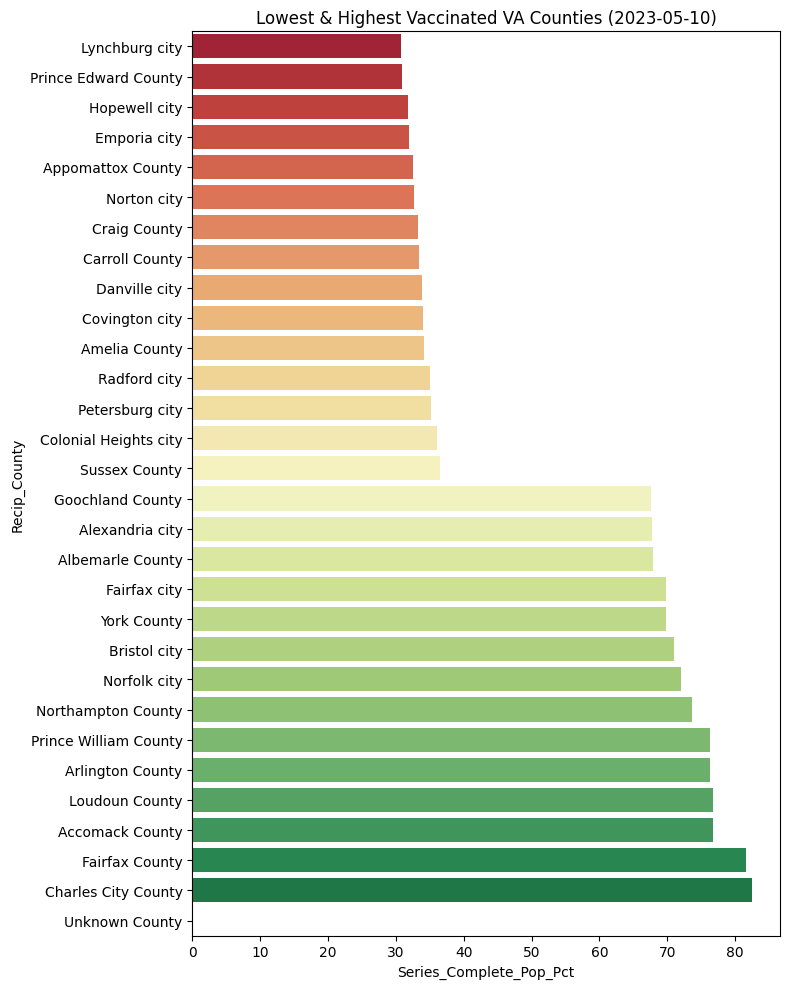

In [21]:
latest_date = vaccinedf['Date'].max()
latest = vaccinedf[vaccinedf['Date'] == latest_date].sort_values('Series_Complete_Pop_Pct')
top_bottom = pd.concat([latest.head(15), latest.tail(15)])

fig, ax = plt.subplots(figsize=(8, 10))
sns.barplot(data=top_bottom, y='Recip_County', x='Series_Complete_Pop_Pct', ax=ax, palette='RdYlGn')
ax.set_title(f'Lowest & Highest Vaccinated VA Counties ({latest_date.date()})')
plt.tight_layout()
plt.show()

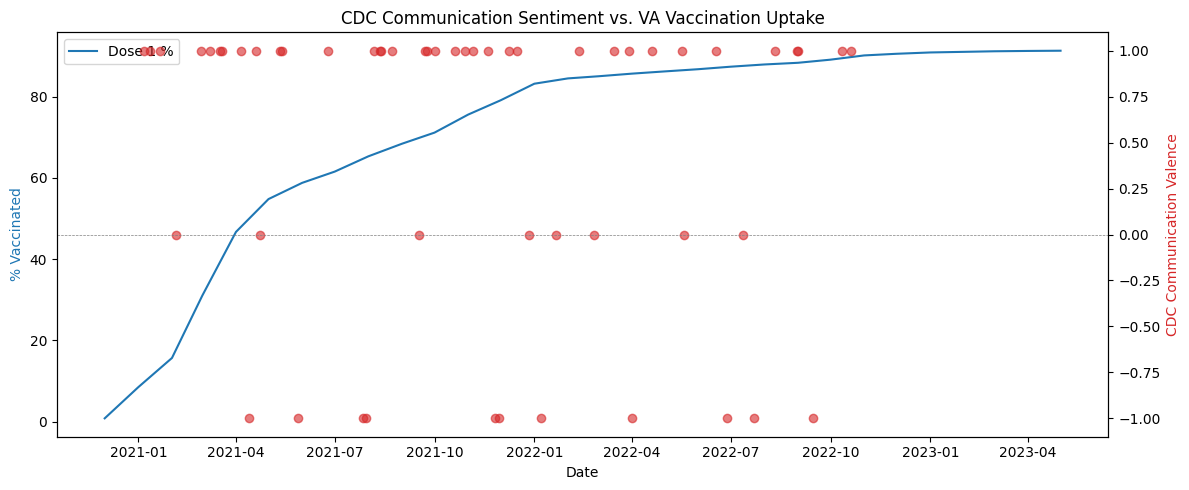

In [22]:
cdccomms['date'] = pd.to_datetime(cdccomms['date'])

fig, ax1 = plt.subplots(figsize=(12, 5))
sns.lineplot(data=monthly, x='Date', y='dose1_pct', ax=ax1, color='tab:blue', label='Dose 1 %')
ax1.set_ylabel('% Vaccinated', color='tab:blue')

ax2 = ax1.twinx()
ax2.scatter(cdccomms['date'], cdccomms['valence'], color='tab:red', alpha=0.6, label='CDC Comm. Valence')
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.5)
ax2.set_ylabel('CDC Communication Valence', color='tab:red')

ax1.set_title('CDC Communication Sentiment vs. VA Vaccination Uptake')
fig.tight_layout()
plt.show()

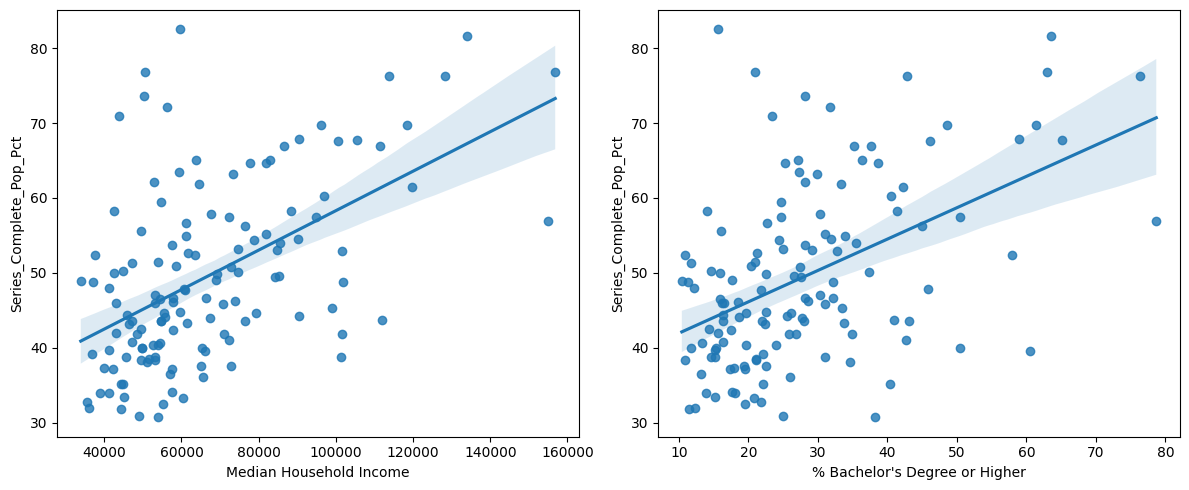

In [23]:
nhgis5['FIPS'] = nhgis5['STATEA'].astype(str).str.zfill(2) + nhgis5['COUNTYA'].astype(str).str.zfill(3)
nhgis5['pct_bachelors_plus'] = (nhgis5['AOP8E022']+nhgis5['AOP8E023']+nhgis5['AOP8E024']+nhgis5['AOP8E025']) / nhgis5['AOP8E001'] * 100

merged = latest.merge(nhgis5[['FIPS','AOQIE001','pct_bachelors_plus']], on='FIPS', how='left')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.regplot(data=merged, x='AOQIE001', y='Series_Complete_Pop_Pct', ax=axes[0])
axes[0].set_xlabel('Median Household Income')
sns.regplot(data=merged, x='pct_bachelors_plus', y='Series_Complete_Pop_Pct', ax=axes[1])
axes[1].set_xlabel('% Bachelor\'s Degree or Higher')
plt.tight_layout()
plt.show()